In [60]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [61]:
text1 = " ‘ andrea ’ sangio ‘ jana ... forver ’ “  together at ferrari”  "
print(replace_quote_symbols(text1))

  <LEFT_SINGLE_QUOTE>  andrea  <RIGHT_SINGLE_QUOTE>  sangio  <LEFT_SINGLE_QUOTE>  jana  <ELLIPSIS>  forver  <RIGHT_SINGLE_QUOTE>   <LEFT_DOUBLE_QUOTE>   together at ferrari <RIGHT_DOUBLE_QUOTE>   


In [62]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return 'n'

def lem_text(text, lemmatizer = WordNetLemmatizer(), tokenizer = WhitespaceTokenizer()):
    tokens = tokenizer.tokenize(text)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
    return " ".join(words)

### Sources:

*   [GloVe Embedding article](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)
*    [Emojis - source1](https://towardsdatascience.com/emojis-aid-social-media-sentiment-analysis-stop-cleaning-them-out-bb32a1e5fc8e)
*   [Emojis - source2](https://medium.com/@HeCanThink/emoji-lets-deal-with-in-python-dcc88b1f8ab1)
*   [Emojis - source3](https://kt.ijs.si/data/Emoji_sentiment_ranking/)
*   [Spell checker - source 1](https://www.johnsnowlabs.com/easily-correcting-typos-and-spelling-errors-on-texts-with-spark-nlp-and-python/)
*   [Spell checker - source 2]()https://stackoverflow.com/questions/69851442/q-python-spell-checker-using-nltk
*   [Lemmatization with a pretrained model - Spark NLP](https://sparknlp.org/2021/11/22/lemma_antbnc_en.html)

In [63]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [64]:
import pandas as pd
import gensim
import emoji
import nltk
import torch
import sys
import shutil
import urllib
import tarfile
from pathlib import Path
import numpy as np
from typing import Iterable
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import gensim.downloader as gloader


import re

## hashtags segmenter
import wordsegment as ws

## mention and lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

In [65]:
# choose right device
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print('Torch Device: %s' % device)

Torch Device: cpu


# Data Visualization

In [66]:
 
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
try:
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    STOPWORDS = set(stopwords.words('english'))

In [67]:
def lower(text):
    return text.lower()

def strip_text(text):
    return text.strip()

def contains_emoji(text):
    return any(emoji.is_emoji(char) for char in text)

def contains_mention(text,MENTION_REGEX = r"@\w+"):
    return re.findall(MENTION_REGEX, text)

def replace_urls_with_token(text,token=" <URL> "):
    url_pattern = r'https?://(?:www\.)?[\w-]+\.[\w/._-]+'
    return re.sub(url_pattern, token, text)

def emoji2description(text):
    return emoji.replace_emoji(text, replace=lambda chars, data_dict: ' '.join(data_dict['en'].split('_')).strip(':')+' ')

def encode_data_with_function(data, encoding, column = 'tweet'):
    data[column] = data[column].apply(encoding)
    return data

def replace_quote_symbols(text):
    text = text.replace("‘", " <LEFT_SINGLE_QUOTE> ")
    text = text.replace("’", " <RIGHT_SINGLE_QUOTE> ")
    text = text.replace("“", " <LEFT_DOUBLE_QUOTE> ")
    text = text.replace("”", " <RIGHT_DOUBLE_QUOTE> ")
    text = text.replace("...", " <ELLIPSIS> ")
    return text

def replace_mention(text,MENTION_REGEX = r"@\w+"):
    mention = re.findall(MENTION_REGEX, text)
    if mention:
        new_sen = text
        for m in mention:
            doc = nlp(m)
            sub = [c.label_ for c in doc.ents]
            if sub:
                new_sen = new_sen.replace(m, f"<{sub[0]}>")
            else:
                new_sen = new_sen.replace(m, f"<{[c.pos_ for c in doc][0]}>")
        return new_sen
    else:
        return text    

def replace_special_characters(text: str) -> str:
    """
    Replaces special characters, such as paranthesis, with spacing character
    """
    return REPLACE_BY_SPACE_RE.sub(' ', text)

def replace_br(text: str) -> str:
    """
    Replaces br characters
    """
    return text.replace('br', '')

def filter_out_uncommon_symbols(text: str) -> str:
    """
    Removes any special character that is not in the good symbols list (check regular expression)
    """
    return GOOD_SYMBOLS_RE.sub('', text)

def remove_stopwords(text: str) -> str:
    return ' '.join([x for x in text.split() if x and x not in STOPWORDS])

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing (including carriage return) from text.
    """
    return text.strip()

In [ ]:
def majority_vote(lst):
    count = Counter(lst)
    return 1 if count.most_common(1)[0][0] == "YES" else 0

def yes_probability(lst):
    # Count the number of YES and NO votes
    yes_count = lst.count("YES")
    no_count = lst.count("NO")
    
    # Calculate the probability of YES
    total = yes_count + no_count
    if total == 0:
        return None  # To handle cases where there are no "YES" or "NO" votes in the list
    else:
        return yes_count / total

def generate_labels_task1(data):
    data = data.drop(['annotators','number_annotators','gender_annotators','age_annotators','labels_task2','labels_task3'],axis=1)
    data['hard_label_task1'] = data['labels_task1'].apply(majority_vote)
    data['soft_label_task1'] = data['labels_task1'].apply(yes_probability)
    return data

def load_and_preprocess_dataset(file_path):
    data = pd.read_json(file_path).T
    data = generate_labels_task1(data)
    columns_to_keep = ['id_EXIST','lang','tweet', 'hard_label_task1','soft_label_task1']
    data = data[columns_to_keep]
    data = filter_english_only(data)
    data = encode_data_with_function(data,emoji2description)
    data = encode_data_with_function(data,replace_mention)
    data = encode_data_with_function(data,replace_urls_with_token) #
    data = encode_data_with_function(data,replace_special_characters)
    data = encode_data_with_function(data,replace_br)
    data = encode_data_with_function(data,filter_out_uncommon_symbols)
    data = encode_data_with_function(data,remove_stopwords)
    data = encode_data_with_function(data,strip_text)
    data = encode_data_with_function(data,replace_quote_symbols)
    data = encode_data_with_function(data,lower)
    data = encode_data_with_function(data,strip_text)
    return data

def filter_english_only(df):
    new_df = df[df['lang'].astype('str').str.contains('en')]
    return new_df


In [69]:
training_data = load_and_preprocess_dataset("data/training.json")
validation_data = load_and_preprocess_dataset("data/validation.json")
test_data = load_and_preprocess_dataset("data/test.json")

In [70]:
print(training_data.shape)
print(validation_data.shape)
print(test_data.shape)

print(training_data.columns)


(3260, 5)
(177, 5)
(312, 5)
Index(['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1'], dtype='object')


In [71]:
display(training_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1
200001,200001,en,ow laying blame bastard murdered ovel idea know,1,0.500000
200002,200002,en,riting uni essay local pub coffee andom old ma...,1,0.833333
200003,200003,en,2021 1921 dont appreciate two rides team membe...,1,0.666667
200004,200004,en,unacceptable se title men interviewed fact sen...,1,0.500000
200005,200005,en,aking harder target basically boils make sure ...,1,0.500000


In [72]:
display(test_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1
400178,400178,en,1st day pool beautiful unday oo bad dared go d...,0,0.000000
400179,400179,en,like outfit except dress frigid bitch try look...,1,0.833333
400180,400180,en,pleading face sparkling heart though angst com...,0,0.000000
400181,400181,en,uck cunt ried vote multiple times,1,0.833333
400182,400182,en,u gotta say shit like ill fuck cunt dumb cant ...,1,1.000000


In [73]:
target = "hard_label_task1"

In [74]:
training_data[target].value_counts()

hard_label_task1
0    1941
1    1319
Name: count, dtype: int64

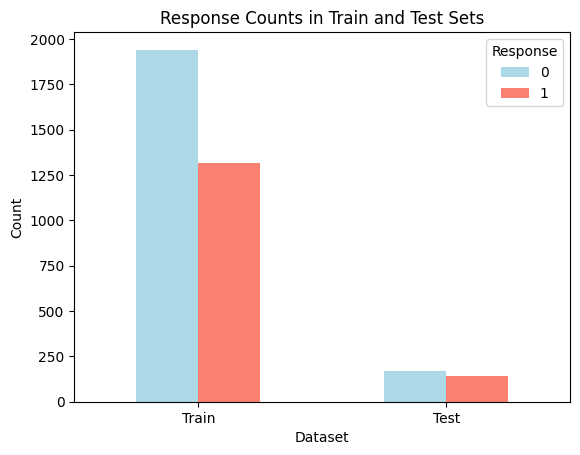

In [75]:
train_counts = training_data[target].value_counts()
test_counts = test_data[target].value_counts()

# Combine counts into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).T  # Transpose to have "yes" and "no" as columns

# Plotting
counts_df.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Response Counts in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

# Data Cleaning

## Mention

To all the training dataset

## Hastags

Thanks to [hashformers](https://github.com/ruanchaves/hashformers) of Ruan Chaves Rodrigues, Marcelo Akira Inuzuka, Juliana Resplande Sant'Anna Gomes, Acquila Santos Rocha, Iacer Calixto, Hugo Alexandre Dantas do Nascimento.

ijijk

In [76]:
hastag_tweets = training_data["tweet"]

In [77]:
def get_hashtags(sentences):
    HASHTAG_REGEX = r"#\w+"
    htags = []
    for sen in sentences:
        htags += re.findall(HASHTAG_REGEX, sen)
    return np.array(htags)

def segment(sentences):
    segmented_sen = []
    for sen in sentences:
        segmented_sen += [np.array(ws.segment(sen))]
    return np.array(segmented_sen, dtype=object)


In [78]:
htags_raw = get_hashtags(hastag_tweets.to_numpy())
print(f"Hashtags found: {htags_raw.size}")
print(f"Hashtag before: {htags_raw}")

Hashtags found: 1234
Hashtag before: ['#verydayexism' '#everydaysexism' '#everydaysexism' ... '#goldengirls'
 '#tandithkriane' '#oldenirls']


In [79]:
# htags = segment(htags_raw)
# print(f"Hashtag after: {htags}")

## Symbols and special charteer

In [81]:
symbols_tweets = training_data["tweet"]

In [82]:
print(symbols_tweets.to_numpy()[8])

#verydayexism e amp need better


In [83]:
def get_symbols(setences):
    symb = []
    for sen in setences:
        symb += re.findall(r'[^\x00-\x7F]+', sen)
    return np.array(symb)

def remove_non_ascii(sentences):
    clean_sentences = []
    for sen in sentences:
        clean_sen = re.sub(r'[^\x00-\x7F]+', '', sen)
        clean_sentences.append(clean_sen)
    return np.array(clean_sentences)

symbol = get_symbols(symbols_tweets.to_numpy())
print(symbol)

[]


## Lemmatization - Same as Tutorial 1

In [84]:

# def lemmatize_sentences(sentences):
#     lemmatized_sentences = []
#     for sen in sentences:
#         doc = nlp(sen)
#         lemmatized_sentence = " ".join([token.lemma_ for token in doc])
#         lemmatized_sentences.append(lemmatized_sentence)
#     return np.array(lemmatized_sentences)

In [85]:
training_data = encode_data_with_function(training_data,lem_text)

# Example
# sentences = ["Cats are running.", "JAHA was cooking some potatoes"]
# #clean_lemmas = lemmatize_sentences(sentences)
# #print(clean_lemmas)
# for sentence in sentences:
#     print(lem_text(sentence))



# Text encoding

In [86]:
embeddings_dict = {}


In [87]:

def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

In [88]:
embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=200)

In [89]:
# with open("C:/Users/andre/Desktop/AlmaMater/NLP/Assignment/Assignment 1/NLP_AssignmentOne/glove.twitter.27B.100d.txt", 'r', encoding="utf-8") as f:
#     for line in f:
#         values = line.split()
#         word = values[0]
#         vector = np.asarray(values[1:], "float32")
#         embeddings_dict[word] = vector

In [90]:
N = 40  # Numero di parole da visualizzare
for i, (word, vector) in enumerate(embeddings_dict.items()):
    print(f"{word}: {vector}")
    if i == N - 1:  # Fermati dopo aver stampato N parole
        break

In [94]:
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)